In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')

In [36]:
df = pd.read_csv('../data/DSA4262 Phone Use Survey.csv')
df_numeric = pd.read_csv('../data/DSA4262 Phone Use Survey.csv')

In [37]:
mapping_phq9 = {
    'Not at all': 0,
    'Several days': 1,
    'More than half the days': 2,
    'Nearly every day': 3
}

phq_cols = df.iloc[:, 35:44].replace(mapping_phq9)
df['PHQ-9 Score'] = phq_cols.sum(axis=1)
df_numeric['PHQ-9 Score'] = phq_cols.sum(axis=1)

mapping_sassv = {
    'Strongly disagree': 1,
    'Disagree': 2,
    'Weakly disagree': 3,
    'Weakly agree': 4,
    'Agree': 5,     
    'Strongly agree': 6
}

sassv_cols = df.iloc[:, 25:35].replace(mapping_sassv)
df['SAS-SV Score'] = sassv_cols.sum(axis=1)
df_numeric['SAS-SV Score'] = sassv_cols.sum(axis=1) 

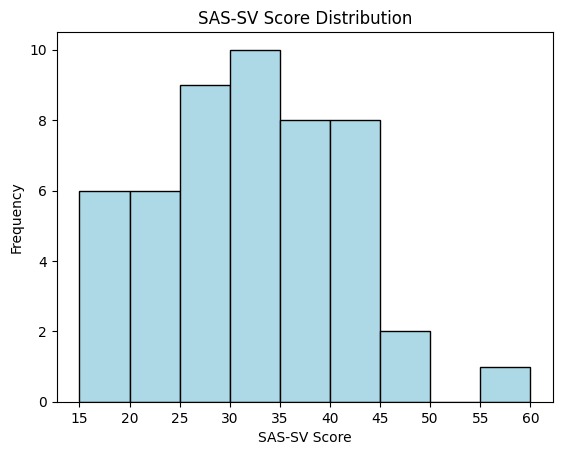

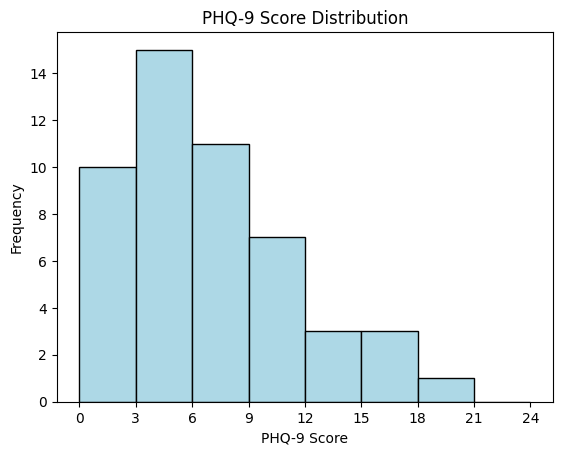

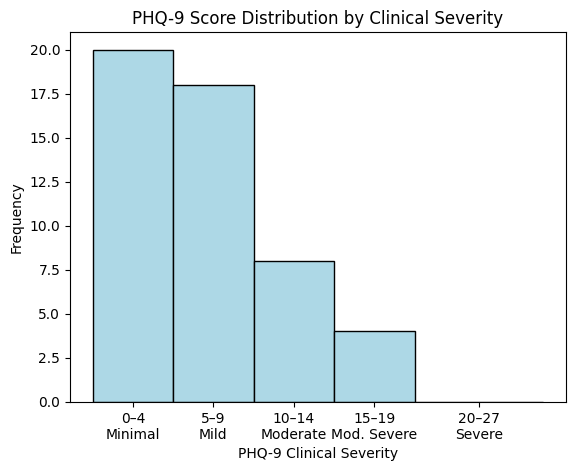

In [39]:
plt.hist(df['SAS-SV Score'], bins=range(15,65,5), edgecolor='black', color='lightblue')
plt.title('SAS-SV Score Distribution')
plt.xticks(range(15,65,5))
plt.xlabel('SAS-SV Score')
plt.ylabel('Frequency')
plt.show()

plt.hist(df['PHQ-9 Score'], bins=range(0,27,3), edgecolor='black', color='lightblue')
plt.title('PHQ-9 Score Distribution')
plt.xticks(range(0,27,3))
plt.xlabel('PHQ-9 Score')
plt.ylabel('Frequency')
plt.show()

phq_bins = [0, 5, 10, 15, 20, 28]
phq_labels = ['0–4\nMinimal', '5–9\nMild', '10–14\nModerate', '15–19\nMod. Severe', '20–27\nSevere']

plt.hist(df['PHQ-9 Score'], bins=phq_bins, edgecolor='black', color='lightblue')
plt.title('PHQ-9 Score Distribution by Clinical Severity')
plt.xlabel('PHQ-9 Clinical Severity')
plt.ylabel('Frequency')
plt.xticks([2.5, 7.5, 12.5, 17.5, 24], phq_labels)
plt.show()

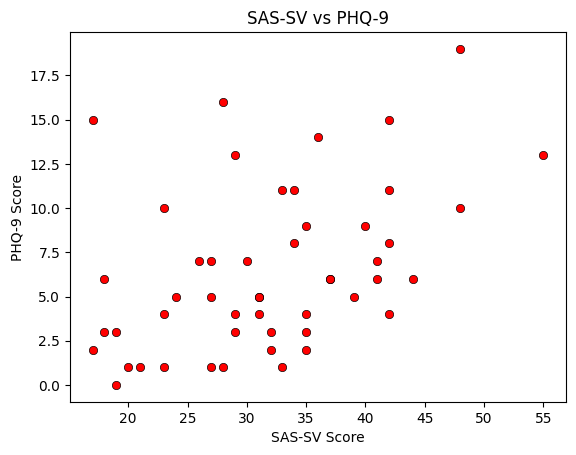

Correlation score between SAS-SV Score and PHQ-9 Score:
0.43126935469428607


In [ ]:
sns.scatterplot(x=df['SAS-SV Score'], y=df['PHQ-9 Score'], color = 'red', edgecolor='black')
plt.title('SAS-SV vs PHQ-9')
plt.show()

print("Correlation score between SAS-SV Score and PHQ-9 Score:")
print(df[['SAS-SV Score', 'PHQ-9 Score']].corr().iloc[0,1])

In [ ]:
df_numeric.drop(['Timestamp', 'Age', 'Gender', 'Occupational / Educational Status'], axis=1, inplace=True)

freq_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Always': 4
}

index_4_map = {
    'Less than 2 hours': 0,
    '2 to 4 hours': 1,
    '4 to 6 hours': 2,
    '6 to 8 hours': 3,
    'More than 8 hours': 4
}

index_5_map = {
    'Less than 20': 0,
    '20 to 50': 1,
    '50 to 100': 2,
    'More than 100': 3
}

index_6_map = {
    'Immediately': 0,
    'Within 5 minutes': 1,
    '5 to 30 minutes': 2,
    'More than 30 minutes': 3
}

index_7_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Almost every night': 4
}

index_8_map = {
    'Before 10pm': 0,
    '10pm to 11pm': 1,
    '11pm to 12am': 2,
    '12am to 1am': 3,
    'After 1am': 4
}

index_10_map = {
    'Less than 30 minutes': 0,
    '30 to 60 minutes': 1,
    '1 to 2 hours': 2,
    '2 to 4 hours': 3,
    'More than 4 hours': 4
}

freq_cols = df.iloc[:, 11:25].columns
df_numeric[freq_cols] = df[freq_cols].replace(freq_map)
df_numeric["On average, how much time did you spend using your smartphone per day in the last 2 weeks?"] = df["On average, how much time did you spend using your smartphone per day in the last 2 weeks?"].replace(index_4_map)
df_numeric["How often do you check your phone in a typical day? (estimate)"] = df["How often do you check your phone in a typical day? (estimate)"].replace(index_5_map)
df_numeric["How soon do you usually check your phone after waking up?"] = df["How soon do you usually check your phone after waking up?"].replace(index_6_map)
df_numeric["How often do you use your phone after 11 PM?"] = df["How often do you use your phone after 11 PM?"].replace(index_7_map)
df_numeric["When do you usually stop using your phone at night?"] = df["When do you usually stop using your phone at night?"].replace(index_8_map)
df_numeric["Approximately how much time per day do you spend on social media apps?"] = df["Approximately how much time per day do you spend on social media apps?"].replace(index_10_map)   

In [ ]:
for col in df_numeric.columns:
    if col != 'PHQ-9 Score' and col != 'SAS-SV Score' and df_numeric[col].dtype in [np.int64, np.float64]:
        print(f"Correlation score between {col} and PHQ-9 Score: {df_numeric[col].corr(df_numeric['PHQ-9 Score'])}")

Correlation score between On average, how much time did you spend using your smartphone per day in the last 2 weeks? and PHQ-9 Score: 0.2034410869053224
Correlation score between How often do you check your phone in a typical day? (estimate) and PHQ-9 Score: 0.1100330377004939
Correlation score between How soon do you usually check your phone after waking up? and PHQ-9 Score: -0.14014045566928596
Correlation score between How often do you use your phone after 11 PM? and PHQ-9 Score: 0.26363261659498083
Correlation score between When do you usually stop using your phone at night? and PHQ-9 Score: 0.0581864308152816
Correlation score between Approximately how much time per day do you spend on social media apps? and PHQ-9 Score: 0.3355324211208847
Correlation score between I use my phone during meals. and PHQ-9 Score: 0.12570196197898992
Correlation score between I use my phone during lectures, meetings, or work. and PHQ-9 Score: 0.21818115730316334
Correlation score between I check my ph

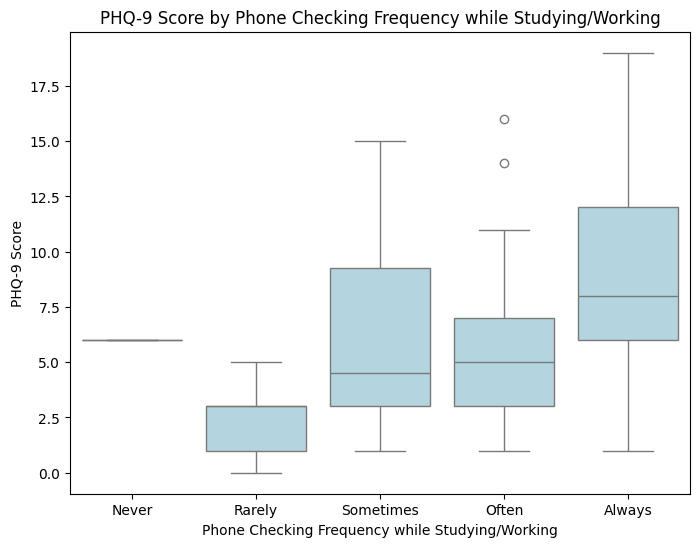

In [ ]:
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['I check my phone while studying or working on tasks.'], y=df['PHQ-9 Score'], order=order, color='lightblue')
plt.title('PHQ-9 Score by Phone Checking Frequency while Studying/Working')
plt.xlabel('Phone Checking Frequency while Studying/Working')
plt.ylabel('PHQ-9 Score')
plt.show()

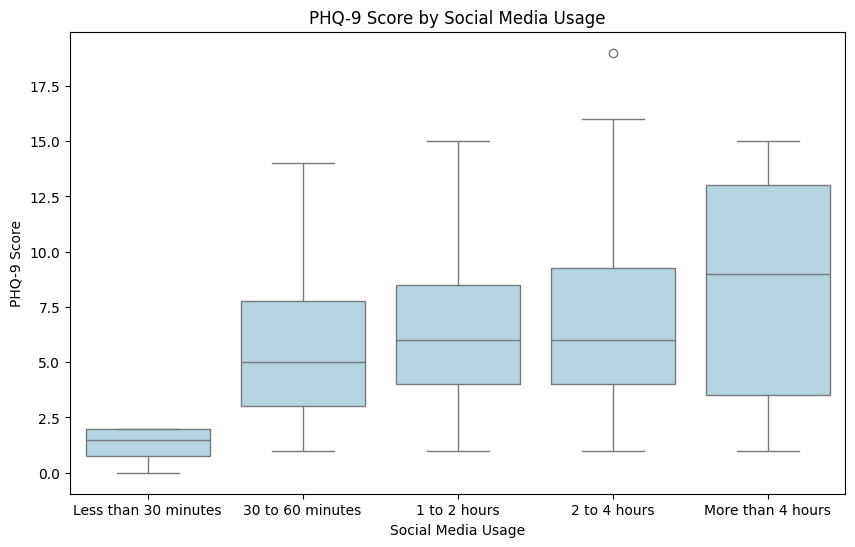

In [ ]:
order = ['Less than 30 minutes', '30 to 60 minutes', '1 to 2 hours', '2 to 4 hours', 'More than 4 hours']
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Approximately how much time per day do you spend on social media apps?'], y=df['PHQ-9 Score'], order=order, color='lightblue')
plt.title('PHQ-9 Score by Social Media Usage')
plt.xlabel('Social Media Usage')
plt.ylabel('PHQ-9 Score')
plt.show()

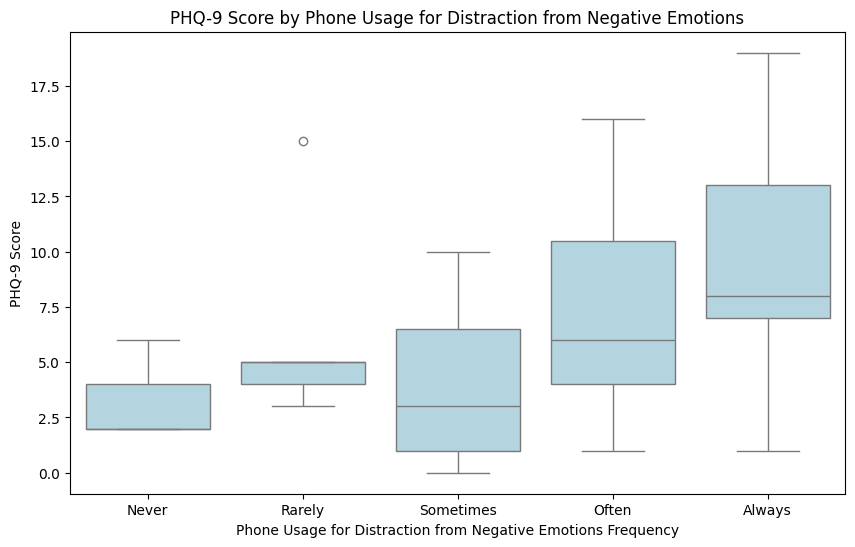

In [ ]:
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['I use my phone to distract myself from negative emotions.'], y=df['PHQ-9 Score'], order=order, color='lightblue')
plt.title('PHQ-9 Score by Phone Usage for Distraction from Negative Emotions')
plt.xlabel('Phone Usage for Distraction from Negative Emotions Frequency')
plt.ylabel('PHQ-9 Score')
plt.show()

In [ ]:
df_numeric["PHQ-9 Group"] = df_numeric['PHQ-9 Score'].apply(lambda x: 'Non-depressive range' if x < 10 else 'Depressive-threshold range')

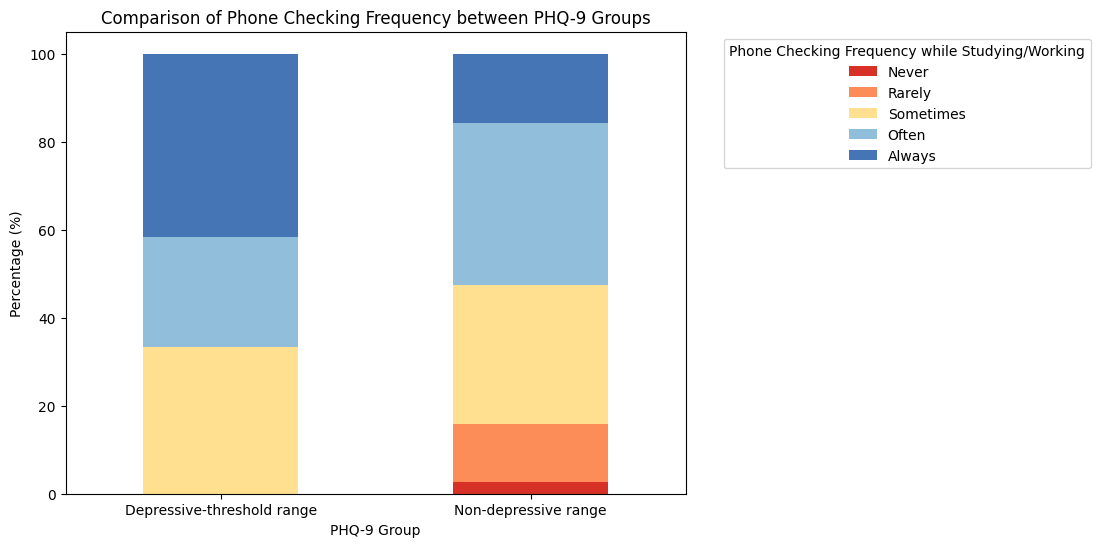

In [ ]:
ct = pd.crosstab(
    df_numeric['PHQ-9 Group'],
    df['I check my phone while studying or working on tasks.'], 
    normalize='index'
) * 100

order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
ct = ct[order]
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
ct.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(8,6)
)

plt.xticks(rotation=0)
plt.ylabel('Percentage (%)')
plt.title('Comparison of Phone Checking Frequency between PHQ-9 Groups')
plt.legend(title='Phone Checking Frequency while Studying/Working', bbox_to_anchor=(1.05, 1))
plt.show()

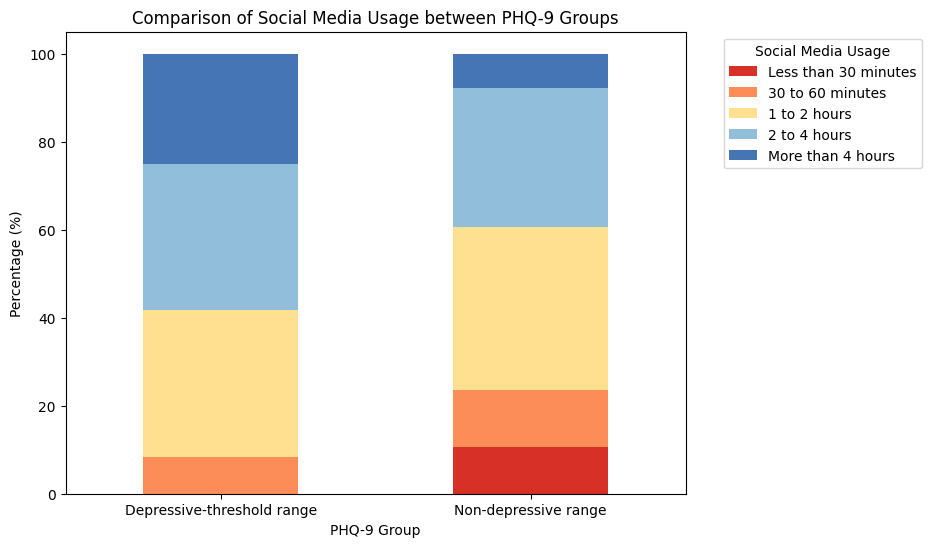

In [ ]:
ct1 = pd.crosstab(
    df_numeric['PHQ-9 Group'],
    df['Approximately how much time per day do you spend on social media apps?'], 
    normalize='index'
) * 100

order = ['Less than 30 minutes', '30 to 60 minutes', '1 to 2 hours', '2 to 4 hours', 'More than 4 hours']
ct1 = ct1[order]
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
ct1.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(8,6)
)

plt.xticks(rotation=0)
plt.ylabel('Percentage (%)')
plt.title('Comparison of Social Media Usage between PHQ-9 Groups')
plt.legend(title='Social Media Usage', bbox_to_anchor=(1.05, 1))
plt.show()

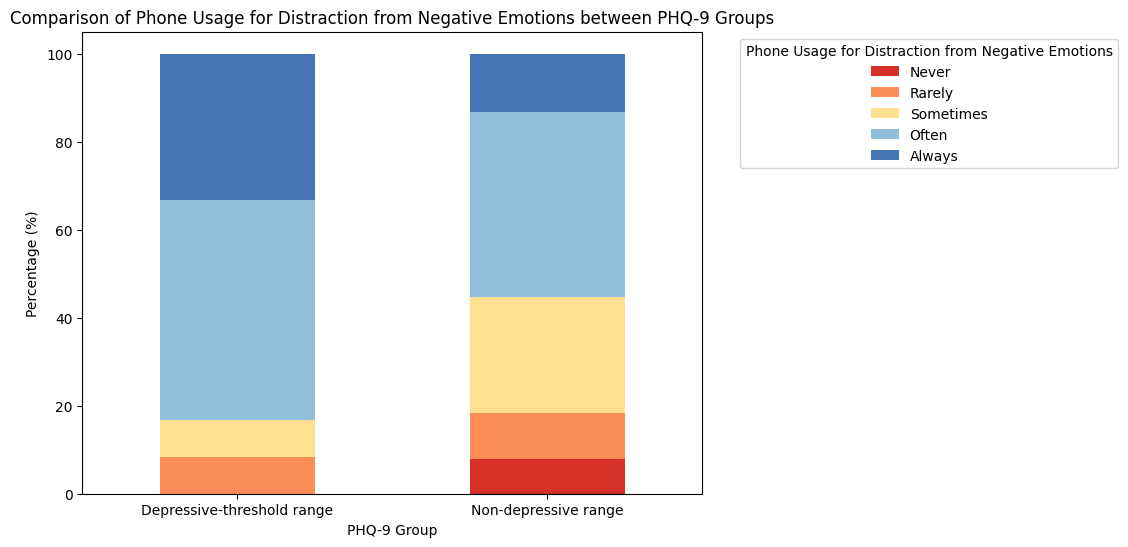

In [ ]:
ct2 = pd.crosstab(
    df_numeric['PHQ-9 Group'],
    df['I use my phone to distract myself from negative emotions.'], 
    normalize='index'
) * 100

order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
ct2 = ct2[order]
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
ct2.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(8,6)
)

plt.xticks(rotation=0)
plt.ylabel('Percentage (%)')
plt.title('Comparison of Phone Usage for Distraction from Negative Emotions between PHQ-9 Groups')
plt.legend(title='Phone Usage for Distraction from Negative Emotions', bbox_to_anchor=(1.05, 1))
plt.show()

# Correlation with Behavioural Domains

In [ ]:
import pandas as pd
import numpy as np


# =========================
# 1. Load dataset
# =========================
df = pd.read_csv("../data/DSA4262_Survey_Cleaned.csv")  # adjust path if needed

# =========================
# 2. Define column groups
# =========================
exposure_intensity = [
    "Q4_DailyPhoneTime_num",
    "Q5_CheckFrequency_num",
    "Q6_AfterWakeCheck_num",
    "Q7_After11PMUse_num",
    "Q8_StopUseAtNight_num",
    "Q10_SocialMediaTime_num"
]

contextual_interference = [
    "Q11_PhoneDuringMeals_num",
    "Q12_PhoneDuringWorkClass_num",
    "Q13_CheckDuringTasks_num",
    "Q14_NotificationsInterrupt_num"
]

emotional_dependence = [
    "Q15_UseWhenBored_num",
    "Q16_UseWhenStressed_num",
    "Q17_DistractNegativeEmotions_num"
]

sleep_disruption = [
    "Q18_PhoneInBed_num",
    "Q19_PhoneDelaysSleep_num",
    "Q20_NotificationsWakeNight_num",
    "Q21_WakeToCheckPhone_num"
]

compulsivity_self_regulation = [
    "Q22_UnlockWithoutReason_num",
    "Q23_UseLongerThanIntended_A_num",
    "Q24_FailToReduceUse_num",
    "Q25_MissPlannedWork_num",
    "Q26_ConcentrationProblems_num",
    "Q28_CannotStandWithoutPhone_num",
    "Q29_ImpatientWithoutPhone_num",
    "Q30_PhoneOnMyMind_num",
    "Q31_WontGiveUpPhone_num",
    "Q32_ConstantChecking_num",
    "Q33_UseLongerThanIntended_B_num",
    "Q34_OthersSayTooMuchUse_num"
]

phq9_cols = [
    "Q35_PHQ1_Interest_num",
    "Q36_PHQ2_Down_num",
    "Q37_PHQ3_Sleep_num",
    "Q38_PHQ4_Tired_num",
    "Q39_PHQ5_Appetite_num",
    "Q40_PHQ6_SelfWorth_num",
    "Q41_PHQ7_Concentration_num",
    "Q42_PHQ8_RestlessSlow_num",
    "Q43_PHQ9_SelfHarm_num"
]

feature_groups = {
    "Exposure intensity": exposure_intensity,
    "Contextual interference": contextual_interference,
    "Emotional dependence": emotional_dependence,
    "Sleep disruption": sleep_disruption,
    "Compulsivity / self-regulation failure": compulsivity_self_regulation
}

# =========================
# 3. Compute PHQ-9 total score
# =========================
df["PHQ9_score"] = df[phq9_cols].sum(axis=1)

# =========================
# 4. Compute Spearman correlations
# =========================
results = []

for group_name, cols in feature_groups.items():
    for col in cols:
        temp = df[[col, "PHQ9_score"]].dropna()

        if len(temp) < 3:
            results.append({
                "Group": group_name,
                "Variable": col,
                "Spearman_rho": np.nan,
                "p_value": np.nan,
                "n": len(temp)
            })
            continue

        rho, pval = spearmanr(temp[col], temp["PHQ9_score"])

        results.append({
            "Group": group_name,
            "Variable": col,
            "Spearman_rho": rho,
            "p_value": pval,
            "n": len(temp)
        })

corr_df = pd.DataFrame(results)

# Sort by absolute correlation strength
corr_df["abs_rho"] = corr_df["Spearman_rho"].abs()
corr_df = corr_df.sort_values("abs_rho", ascending=False).drop(columns="abs_rho")

# =========================
# 5. Optional: add cleaner labels
# =========================
label_map = {
    "Q4_DailyPhoneTime_num": "Daily screen time",
    "Q5_CheckFrequency_num": "Checking frequency",
    "Q6_AfterWakeCheck_num": "Soon after waking",
    "Q7_After11PMUse_num": "Use after 11 PM",
    "Q8_StopUseAtNight_num": "Stopping time at night",
    "Q10_SocialMediaTime_num": "Social media time",

    "Q11_PhoneDuringMeals_num": "During meals",
    "Q12_PhoneDuringWorkClass_num": "During lectures/meetings/work",
    "Q13_CheckDuringTasks_num": "While studying/working",
    "Q14_NotificationsInterrupt_num": "Notifications interrupt concentration",

    "Q15_UseWhenBored_num": "Use when bored",
    "Q16_UseWhenStressed_num": "Use when stressed",
    "Q17_DistractNegativeEmotions_num": "Use to distract from negative emotions",

    "Q18_PhoneInBed_num": "Use in bed",
    "Q19_PhoneDelaysSleep_num": "Delays sleep",
    "Q20_NotificationsWakeNight_num": "Notifications wake user",
    "Q21_WakeToCheckPhone_num": "Wake in the night to check phone",

    "Q22_UnlockWithoutReason_num": "Unlock without clear reason",
    "Q23_UseLongerThanIntended_A_num": "Use longer than intended (A)",
    "Q24_FailToReduceUse_num": "Try to reduce but fail",
    "Q25_MissPlannedWork_num": "Miss planned work",
    "Q26_ConcentrationProblems_num": "Concentration impaired",
    "Q28_CannotStandWithoutPhone_num": "Cannot stand not having phone",
    "Q29_ImpatientWithoutPhone_num": "Impatient when not holding phone",
    "Q30_PhoneOnMyMind_num": "Think about phone when not using",
    "Q31_WontGiveUpPhone_num": "Never give up phone even when life affected",
    "Q32_ConstantChecking_num": "Constantly check not to miss things",
    "Q33_UseLongerThanIntended_B_num": "Use longer than intended (B)",
    "Q34_OthersSayTooMuchUse_num": "Others say use too much"
}

corr_df["Label"] = corr_df["Variable"].map(label_map)

# Reorder columns
corr_df = corr_df[["Group", "Variable", "Label", "Spearman_rho", "p_value", "n"]]

# =========================
# 6. Display results
# =========================
print(corr_df.to_string(index=False))

# Save to CSV if needed
corr_df.to_csv("phq9_spearman_correlations.csv", index=False)

                                 Group                         Variable                                       Label  Spearman_rho  p_value  n
Compulsivity / self-regulation failure            Q30_PhoneOnMyMind_num            Think about phone when not using      0.428913 0.001884 50
Compulsivity / self-regulation failure    Q29_ImpatientWithoutPhone_num            Impatient when not holding phone      0.368269 0.008504 50
                  Emotional dependence Q17_DistractNegativeEmotions_num      Use to distract from negative emotions      0.363828 0.009397 50
               Contextual interference         Q13_CheckDuringTasks_num                      While studying/working      0.344732 0.014221 50
Compulsivity / self-regulation failure    Q26_ConcentrationProblems_num                      Concentration impaired      0.340161 0.015648 50
                  Emotional dependence          Q16_UseWhenStressed_num                           Use when stressed      0.316096 0.025333 50
      

In [ ]:

df = pd.read_csv("../data/DSA4262_Survey_Cleaned.csv") 


# Define column groups
exposure_intensity = [
    "Q4_DailyPhoneTime_num",
    "Q5_CheckFrequency_num",
    "Q6_AfterWakeCheck_num",
    "Q7_After11PMUse_num",
    "Q8_StopUseAtNight_num",
    "Q10_SocialMediaTime_num"
]

contextual_interference = [
    "Q11_PhoneDuringMeals_num",
    "Q12_PhoneDuringWorkClass_num",
    "Q13_CheckDuringTasks_num",
    "Q14_NotificationsInterrupt_num"
]

emotional_dependence = [
    "Q15_UseWhenBored_num",
    "Q16_UseWhenStressed_num",
    "Q17_DistractNegativeEmotions_num"
]

sleep_disruption = [
    "Q18_PhoneInBed_num",
    "Q19_PhoneDelaysSleep_num",
    "Q20_NotificationsWakeNight_num",
    "Q21_WakeToCheckPhone_num"
]

compulsivity_self_regulation = [
    "Q22_UnlockWithoutReason_num",
    "Q23_UseLongerThanIntended_A_num",
    "Q24_FailToReduceUse_num",
    "Q25_MissPlannedWork_num",
    "Q26_ConcentrationProblems_num",
    "Q28_CannotStandWithoutPhone_num",
    "Q29_ImpatientWithoutPhone_num",
    "Q30_PhoneOnMyMind_num",
    "Q31_WontGiveUpPhone_num",
    "Q32_ConstantChecking_num",
    "Q33_UseLongerThanIntended_B_num",
    "Q34_OthersSayTooMuchUse_num"
]

phq9_cols = [
    "Q35_PHQ1_Interest_num",
    "Q36_PHQ2_Down_num",
    "Q37_PHQ3_Sleep_num",
    "Q38_PHQ4_Tired_num",
    "Q39_PHQ5_Appetite_num",
    "Q40_PHQ6_SelfWorth_num",
    "Q41_PHQ7_Concentration_num",
    "Q42_PHQ8_RestlessSlow_num",
    "Q43_PHQ9_SelfHarm_num"
]


# Compute PHQ-9 total score
df["PHQ9_score"] = df[phq9_cols].sum(axis=1)


# Compute subscale scores
# Use mean so scales are comparable
df["ExposureIntensity_score"] = df[exposure_intensity].mean(axis=1)
df["ContextualInterference_score"] = df[contextual_interference].mean(axis=1)
df["EmotionalDependence_score"] = df[emotional_dependence].mean(axis=1)
df["SleepDisruption_score"] = df[sleep_disruption].mean(axis=1)
df["Compulsivity_score"] = df[compulsivity_self_regulation].mean(axis=1)

subscale_cols = [
    "ExposureIntensity_score",
    "ContextualInterference_score",
    "EmotionalDependence_score",
    "SleepDisruption_score",
    "Compulsivity_score"
]

# Compute Spearman correlations
results = []

for col in subscale_cols:
    temp = df[[col, "PHQ9_score"]].dropna()

    rho, pval = spearmanr(temp[col], temp["PHQ9_score"])

    results.append({
        "Subscale": col,
        "Spearman_rho": rho,
        "p_value": pval,
        "n": len(temp)
    })

subscale_corr_df = pd.DataFrame(results)

# Sort by absolute correlation strength
subscale_corr_df["abs_rho"] = subscale_corr_df["Spearman_rho"].abs()
subscale_corr_df = subscale_corr_df.sort_values("abs_rho", ascending=False).drop(columns="abs_rho")

print(subscale_corr_df.to_string(index=False))

                    Subscale  Spearman_rho  p_value  n
   EmotionalDependence_score      0.387938 0.005374 50
ContextualInterference_score      0.380057 0.006481 50
          Compulsivity_score      0.367533 0.008647 50
     ExposureIntensity_score      0.283917 0.045701 50
       SleepDisruption_score      0.188045 0.190958 50


                                 Subscale                        Column  \
3                        Sleep disruption         SleepDisruption_score   
0                      Exposure intensity       ExposureIntensity_score   
4  Compulsivity / self-regulation failure            Compulsivity_score   
1                 Contextual interference  ContextualInterference_score   
2                    Emotional dependence     EmotionalDependence_score   

   Spearman_rho   p_value  
3      0.188045  0.190958  
0      0.283917  0.045701  
4      0.367533  0.008647  
1      0.380057  0.006481  
2      0.387938  0.005374  


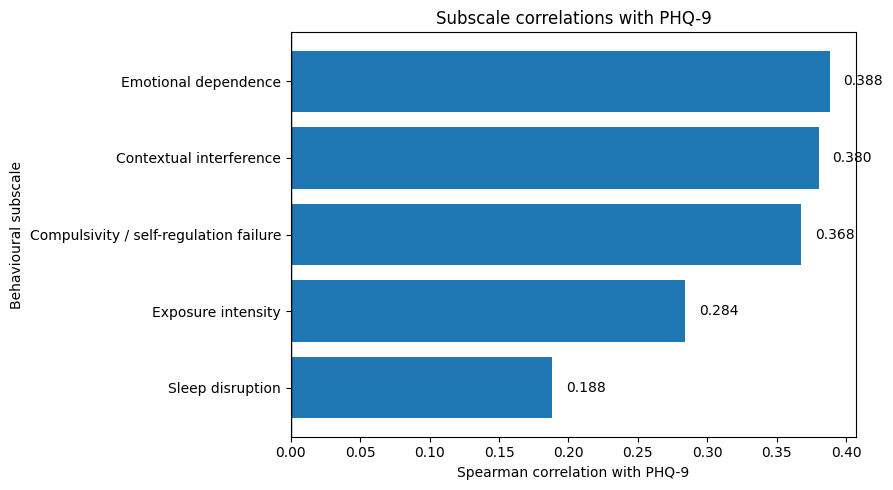

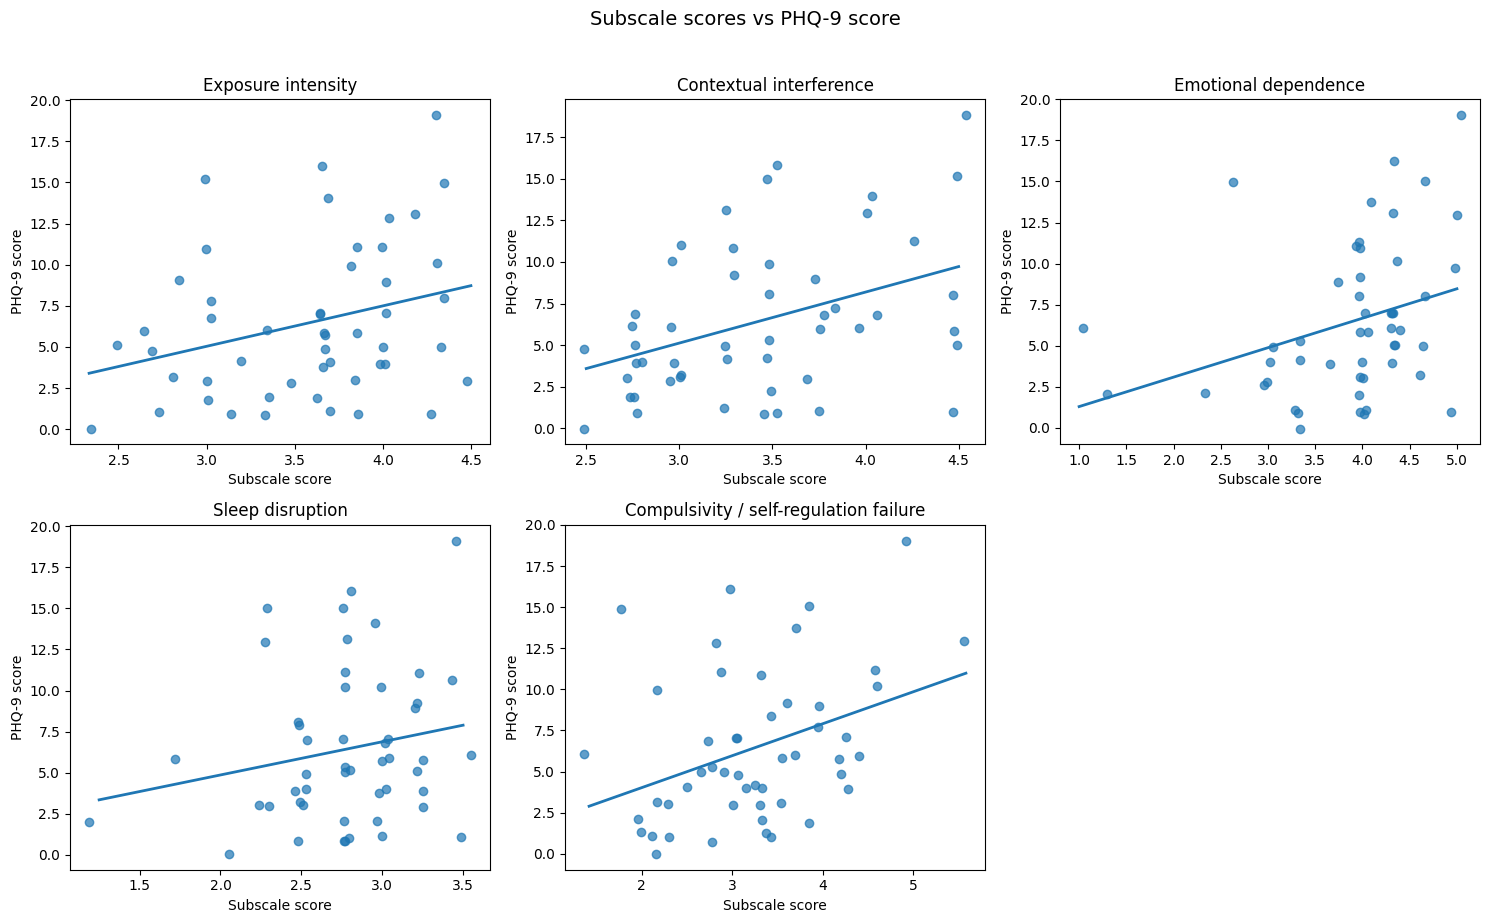

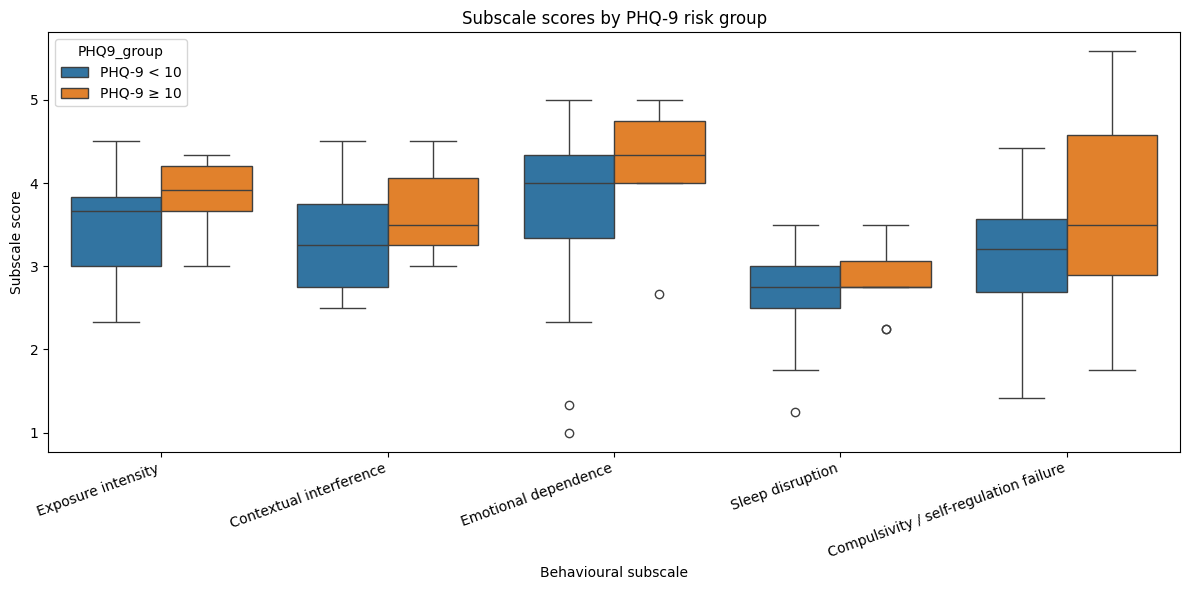

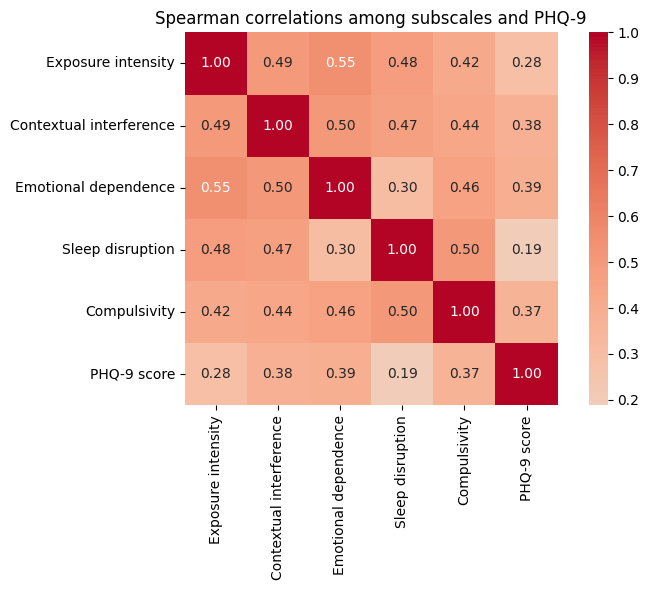

In [ ]:
df = pd.read_csv("../data/DSA4262_Survey_Cleaned.csv")  

# Define column groups
exposure_intensity = [
    "Q4_DailyPhoneTime_num",
    "Q5_CheckFrequency_num",
    "Q6_AfterWakeCheck_num",
    "Q7_After11PMUse_num",
    "Q8_StopUseAtNight_num",
    "Q10_SocialMediaTime_num"
]

contextual_interference = [
    "Q11_PhoneDuringMeals_num",
    "Q12_PhoneDuringWorkClass_num",
    "Q13_CheckDuringTasks_num",
    "Q14_NotificationsInterrupt_num"
]

emotional_dependence = [
    "Q15_UseWhenBored_num",
    "Q16_UseWhenStressed_num",
    "Q17_DistractNegativeEmotions_num"
]

sleep_disruption = [
    "Q18_PhoneInBed_num",
    "Q19_PhoneDelaysSleep_num",
    "Q20_NotificationsWakeNight_num",
    "Q21_WakeToCheckPhone_num"
]

compulsivity_self_regulation = [
    "Q22_UnlockWithoutReason_num",
    "Q23_UseLongerThanIntended_A_num",
    "Q24_FailToReduceUse_num",
    "Q25_MissPlannedWork_num",
    "Q26_ConcentrationProblems_num",
    "Q28_CannotStandWithoutPhone_num",
    "Q29_ImpatientWithoutPhone_num",
    "Q30_PhoneOnMyMind_num",
    "Q31_WontGiveUpPhone_num",
    "Q32_ConstantChecking_num",
    "Q33_UseLongerThanIntended_B_num",
    "Q34_OthersSayTooMuchUse_num"
]

phq9_cols = [
    "Q35_PHQ1_Interest_num",
    "Q36_PHQ2_Down_num",
    "Q37_PHQ3_Sleep_num",
    "Q38_PHQ4_Tired_num",
    "Q39_PHQ5_Appetite_num",
    "Q40_PHQ6_SelfWorth_num",
    "Q41_PHQ7_Concentration_num",
    "Q42_PHQ8_RestlessSlow_num",
    "Q43_PHQ9_SelfHarm_num"
]

# Compute PHQ-9 total and subscales
df["PHQ9_score"] = df[phq9_cols].sum(axis=1)

df["ExposureIntensity_score"] = df[exposure_intensity].mean(axis=1)
df["ContextualInterference_score"] = df[contextual_interference].mean(axis=1)
df["EmotionalDependence_score"] = df[emotional_dependence].mean(axis=1)
df["SleepDisruption_score"] = df[sleep_disruption].mean(axis=1)
df["Compulsivity_score"] = df[compulsivity_self_regulation].mean(axis=1)

subscale_map = {
    "Exposure intensity": "ExposureIntensity_score",
    "Contextual interference": "ContextualInterference_score",
    "Emotional dependence": "EmotionalDependence_score",
    "Sleep disruption": "SleepDisruption_score",
    "Compulsivity / self-regulation failure": "Compulsivity_score"
}

subscale_cols = list(subscale_map.values())

# Compute subscale correlations with PHQ-9
corr_results = []
for label, col in subscale_map.items():
    temp = df[[col, "PHQ9_score"]].dropna()
    rho, pval = spearmanr(temp[col], temp["PHQ9_score"])
    corr_results.append({
        "Subscale": label,
        "Column": col,
        "Spearman_rho": rho,
        "p_value": pval
    })

corr_df = pd.DataFrame(corr_results).sort_values("Spearman_rho", ascending=True)

print(corr_df)

# Horizontal bar chart of subscale correlations
plt.figure(figsize=(9, 5))
bars = plt.barh(corr_df["Subscale"], corr_df["Spearman_rho"])
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Spearman correlation with PHQ-9")
plt.ylabel("Behavioural subscale")
plt.title("Subscale correlations with PHQ-9")

for i, v in enumerate(corr_df["Spearman_rho"]):
    plt.text(v + 0.01 if v >= 0 else v - 0.08, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()


# Scatter plots with jitter for each subscale vs PHQ-9
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

rng = np.random.default_rng(42)

for i, (label, col) in enumerate(subscale_map.items()):
    temp = df[[col, "PHQ9_score"]].dropna().copy()

    x_jitter = temp[col] + rng.normal(0, 0.03, size=len(temp))
    y_jitter = temp["PHQ9_score"] + rng.normal(0, 0.15, size=len(temp))

    axes[i].scatter(x_jitter, y_jitter, alpha=0.7)
    
    # simple linear trend line for visual aid
    z = np.polyfit(temp[col], temp["PHQ9_score"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(temp[col].min(), temp[col].max(), 100)
    axes[i].plot(x_line, p(x_line), linewidth=2)

    axes[i].set_title(label)
    axes[i].set_xlabel("Subscale score")
    axes[i].set_ylabel("PHQ-9 score")

# Hide unused last subplot
axes[-1].axis("off")

plt.suptitle("Subscale scores vs PHQ-9 score", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Boxplots of subscale scores by PHQ-9 risk group
df["PHQ9_group"] = np.where(df["PHQ9_score"] >= 10, "PHQ-9 ≥ 10", "PHQ-9 < 10")

plot_df = df.melt(
    id_vars=["PHQ9_group"],
    value_vars=subscale_cols,
    var_name="Subscale",
    value_name="Score"
)

reverse_label_map = {v: k for k, v in subscale_map.items()}
plot_df["Subscale"] = plot_df["Subscale"].map(reverse_label_map)

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x="Subscale", y="Score", hue="PHQ9_group")
plt.xticks(rotation=20, ha="right")
plt.title("Subscale scores by PHQ-9 risk group")
plt.xlabel("Behavioural subscale")
plt.ylabel("Subscale score")
plt.tight_layout()
plt.show()

# Heatmap of correlations among subscales and PHQ-9
heatmap_cols = subscale_cols + ["PHQ9_score"]
heatmap_df = df[heatmap_cols].copy()

corr_matrix = heatmap_df.corr(method="spearman")

pretty_names = {
    "ExposureIntensity_score": "Exposure intensity",
    "ContextualInterference_score": "Contextual interference",
    "EmotionalDependence_score": "Emotional dependence",
    "SleepDisruption_score": "Sleep disruption",
    "Compulsivity_score": "Compulsivity",
    "PHQ9_score": "PHQ-9 score"
}

corr_matrix = corr_matrix.rename(index=pretty_names, columns=pretty_names)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Spearman correlations among subscales and PHQ-9")
plt.tight_layout()
plt.show()